In [ ]:
# Grundläggande bibliotek
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Train/validation-split
from sklearn.model_selection import train_test_split

#import sys
#!{sys.executable} -m pip install tensorflow

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.utils.set_random_seed(42)


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached tensorflow-2.21.0-cp311-cp311-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached wrapt-2.1.2-cp311-cp311-win_amd64.whl.metadata (7.6 kB)
  Using cached grpcio-1.80.0-cp311-cp311-win_amd64.whl.metadata (3.9 kB)
  Using cached h5py-3.14.0-cp311-cp311-win_amd64.whl.metadata (2.7 kB)
  Using cached ml_dtypes-0.5.4-cp311-cp311-win_amd64.whl.metadata (9.2 kB)
  Us

In [5]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

print("X_train_full shape:", X_train_full.shape)
print("y_train_full shape:", y_train_full.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train_full shape: (60000, 28, 28)
y_train_full shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [6]:
print("Unika labels:", np.unique(y_train_full))

print("Minsta pixelvärde:", X_train_full.min())
print("Största pixelvärde:", X_train_full.max())

Unika labels: [0 1 2 3 4 5 6 7 8 9]
Minsta pixelvärde: 0
Största pixelvärde: 255


In [8]:
# Class names
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

# Example: print first label and its name
print(y_train_full[0])
print(class_names[y_train_full[0]])

9
Ankle boot


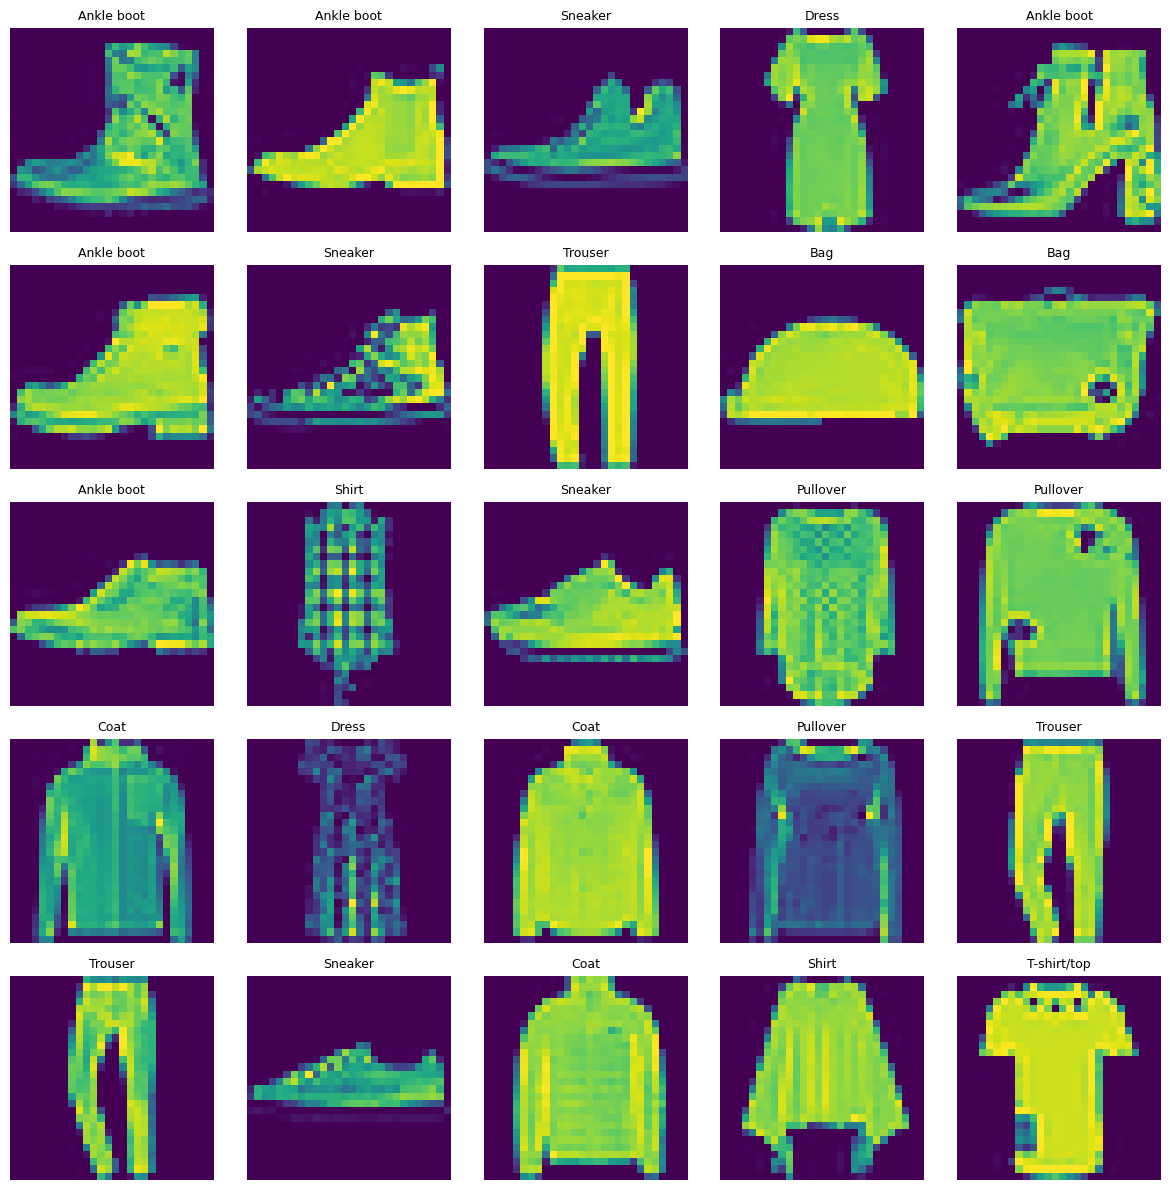

In [9]:
def  plot_image_grid(X, y, class_names, n_images=25, random_state=42):
    rng = np.random.default_rng(random_state)
    indices = rng.choice(len(X), size=n_images, replace=False)

    grid_size = int(np.ceil(np.sqrt(n_images)))

    plt.figure(figsize=(12, 12))
    
    for plot_index, image_index in enumerate(indices):
        plt.subplot(grid_size, grid_size, plot_index + 1)
        plt.imshow(X[image_index])
        plt.title(class_names[y[image_index]], fontsize=9)
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()


plot_image_grid(
    X_train_full,
    y_train_full,
    class_names,
    n_images=25
)